In [21]:
import pandas as pd
import os

# Example: Load orders dataset
orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
payments = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))

print(orders.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [22]:

import pandas as pd

# Load datasets 
orders       = pd.read_csv(path + "/olist_orders_dataset.csv")
customers    = pd.read_csv(path + "/olist_customers_dataset.csv")
reviews      = pd.read_csv(path + "/olist_order_reviews_dataset.csv")
order_items  = pd.read_csv(path + "/olist_order_items_dataset.csv")
payments     = pd.read_csv(path + "/olist_order_payments_dataset.csv")
products     = pd.read_csv(path + "/olist_products_dataset.csv")
sellers      = pd.read_csv(path + "/olist_sellers_dataset.csv")
translation  = pd.read_csv(path + "/product_category_name_translation.csv")

# 2. Data Merging – Create Master Dataset
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(reviews, on='order_id', how='left')
df = df.merge(order_items, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(translation, on='product_category_name', how='left')

# 3. Convert Date Columns
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 4. Feature Engineering

df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_approved_at']
).dt.days

df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')

df['delivery_delay'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['revenue'] = df['price'] + df['freight_value']

print(" Master dataset created with shape:", df.shape)
df.head()


 Master dataset created with shape: (119143, 44)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,delivery_time,purchase_month,delivery_delay,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.00,13.00,"9,350.00",maua,SP,housewares,8.00,2017-10,-8.00,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.00,13.00,"9,350.00",maua,SP,housewares,8.00,2017-10,-8.00,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.00,13.00,"9,350.00",maua,SP,housewares,8.00,2017-10,-8.00,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,13.00,19.00,"31,570.00",belo horizonte,SP,perfumery,12.00,2018-07,-6.00,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.00,21.00,"14,840.00",guariba,SP,auto,9.00,2018-08,-18.00,179.12


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

#  Monthly Sales Trend


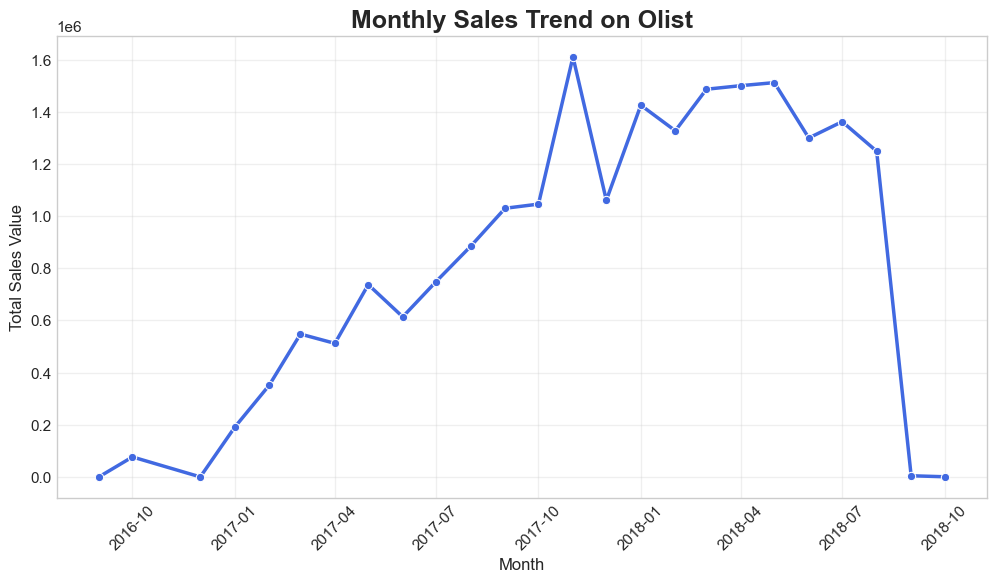

In [19]:

monthly_sales = df.groupby('purchase_month')['payment_value'].sum().to_timestamp()

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='royalblue', linewidth=2.5)
plt.title('Monthly Sales Trend on Olist', fontsize=18, weight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# Top 10 Product Categories by Revenue


C:\Users\hp\AppData\Local\Temp\ipykernel_7708\607092704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


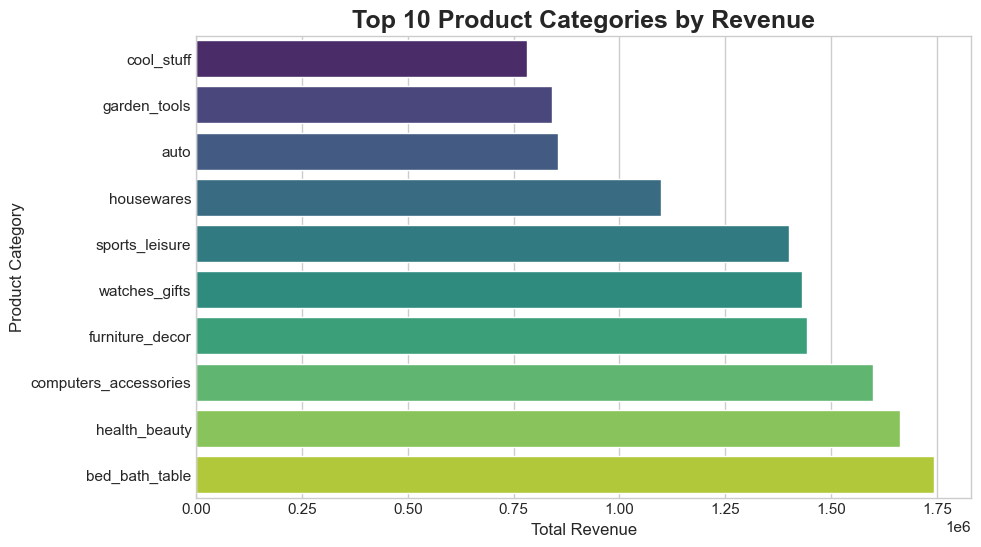

In [18]:

top_categories = df.groupby('product_category_name_english')['payment_value'] \
                   .sum().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=18, weight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.show()

# Top 10 Customer States by Order Count


C:\Users\hp\AppData\Local\Temp\ipykernel_7708\171365040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette='magma')


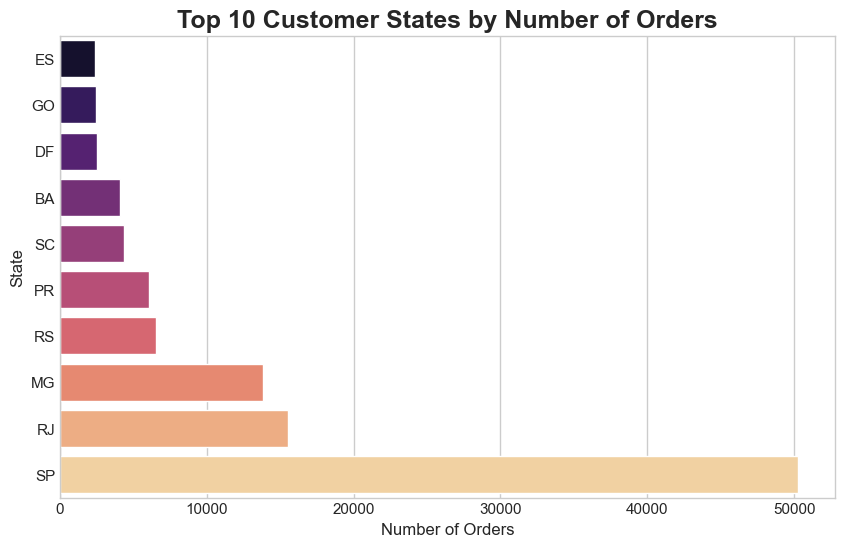

In [17]:

top_states = df['customer_state'].value_counts().nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, palette='magma')
plt.title('Top 10 Customer States by Number of Orders', fontsize=18, weight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.show()

#  Review Score Distribution


C:\Users\hp\AppData\Local\Temp\ipykernel_7708\1517209285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=review_scores.index, y=review_scores.values, palette='coolwarm')


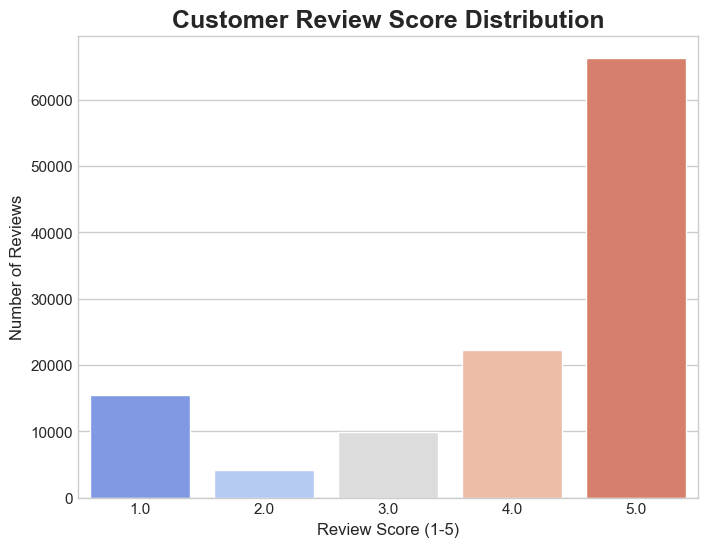

In [16]:

review_scores = df['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.barplot(x=review_scores.index, y=review_scores.values, palette='coolwarm')
plt.title('Customer Review Score Distribution', fontsize=18, weight='bold')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

#  Delivery Time vs. Review Score


C:\Users\hp\AppData\Local\Temp\ipykernel_7708\1384197256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_vs_review.index, y=delivery_vs_review.values, palette='Set2')


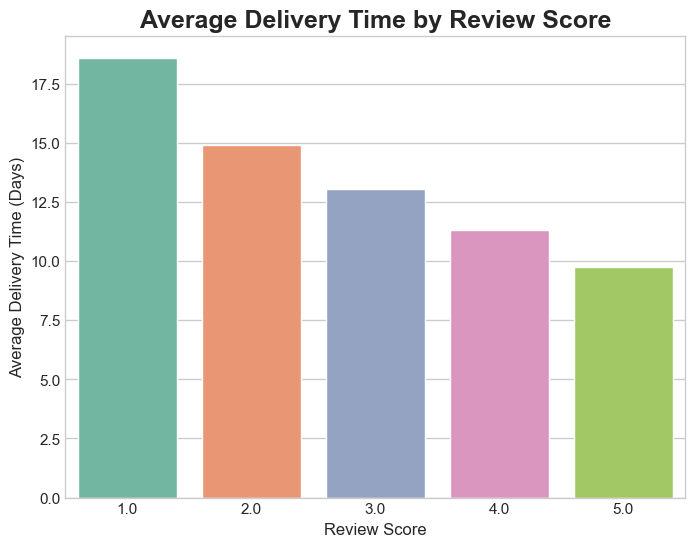

In [15]:

delivery_vs_review = df.groupby('review_score')['delivery_time'].mean()

plt.figure(figsize=(8,6))
sns.barplot(x=delivery_vs_review.index, y=delivery_vs_review.values, palette='Set2')
plt.title('Average Delivery Time by Review Score', fontsize=18, weight='bold')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Time (Days)')
plt.xticks(rotation=0)
plt.show()

#  Project Summary – Olist E-commerce Analysis  

This project provides an **end-to-end analysis** of the Olist E-commerce dataset, covering data preprocessing, trend analysis, customer insights, and segmentation.  

##  Key Insights  

- **Monthly Sales Trend**  
  - Sales show clear seasonal patterns with peaks in specific months.  

- **Top Product Categories**  
  - Categories like *bed_bath_table* and *health_beauty* drive the highest revenue.  

- **Customer States**  
  - Majority of orders come from a handful of top states, highlighting regional concentration.  

- **Customer Reviews**  
  - Most reviews are positive (4–5 stars), but delivery delays impact lower ratings.  

- **Delivery vs. Reviews**  
  - Faster deliveries are strongly linked with better customer reviews.  

- **Payment Methods**  
  - Credit cards dominate payments, but boleto and debit are still widely used.  

- **Customer Segmentation (RFM Analysis)**  
  - Customers are segmented into **Champions, Loyal, At Risk, and One-time buyers**, helping identify retention and growth opportunities.  

##  Business Value  

This analysis empowers businesses to:  
- Optimize **product strategy** by focusing on top revenue categories.  
- Improve **logistics & delivery speed** to enhance reviews.  
- Tailor **marketing campaigns** based on customer segments.  
- Enhance **regional targeting** by focusing on high-order states.  

---

 **Final Note**: By combining sales, customer behavior, reviews, and payments, this project delivers a **comprehensive view of Olist’s marketplace performance** and provides actionable insights for business growth.  
